Using device: cuda
Feature matrix : (6681, 1280)
Label counts   : [3471 3210]

================ Starting 10-Fold Cross-Validation (CNN-Transformer) ================
  Fold 01: early stopping at epoch 22 (best val_loss=0.3040)
Fold 01/10 | Acc: 88.49% | Sens: 89.41% | Spec: 87.64% | Precision: 86.97% | F1: 88.17% | MCC: 0.7700 | AUC: 0.9559
  Fold 02: early stopping at epoch 18 (best val_loss=0.3689)
Fold 02/10 | Acc: 87.72% | Sens: 84.11% | Spec: 91.07% | Precision: 89.70% | F1: 86.82% | MCC: 0.7549 | AUC: 0.9341
  Fold 03: early stopping at epoch 14 (best val_loss=0.3118)
Fold 03/10 | Acc: 87.28% | Sens: 77.26% | Spec: 96.54% | Precision: 95.38% | F1: 85.37% | MCC: 0.7562 | AUC: 0.9308
  Fold 04: early stopping at epoch 25 (best val_loss=0.2507)
Fold 04/10 | Acc: 92.22% | Sens: 86.60% | Spec: 97.41% | Precision: 96.86% | F1: 91.45% | MCC: 0.8479 | AUC: 0.9504
  Fold 05: early stopping at epoch 16 (best val_loss=0.2556)
Fold 05/10 | Acc: 91.47% | Sens: 85.05% | Spec: 97.41% | Precision

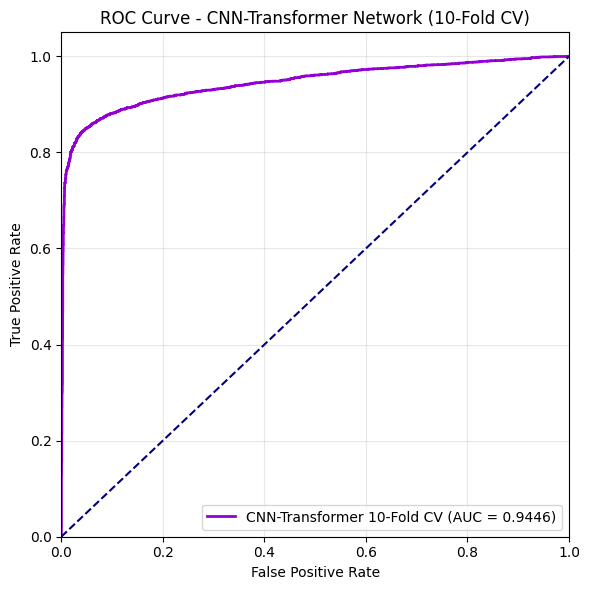


Saved: CNN_Transformer_10Fold_Detailed_Folds.csv
Saved: CNN_Transformer_10Fold_MeanStd_Summary.csv
Saved: CNN_Transformer_10Fold_Results.csv
Saved: ROC_CNN_Transformer_10Fold.png
Saved: roc_values_cnn_transformer.npz


In [ ]:
"""
ESM-2 + CNN + Transformer + FCN Model — Complete 10-Fold CV Pipeline
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : Stratified 10-Fold Cross-Validation on 100% Data Pool
Batch   : 32
Epochs  : up to 100 per fold, with early stopping on validation loss
Outputs : Fold-wise & Mean±Std Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + ROC curve variables (fpr_cnn_transformer, tpr_cnn_transformer, roc_auc_cnn_transformer)

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> Multi-Kernel Conv1D Layers (CNN Local Feature Extractor)
                 -> Multi-Head Self-Attention Blocks (Transformer Encoder)
                 -> Global Dual Pooling (Mean + Max over sequence)
                 -> Deep Residual Fully Connected Network (FCN)
                 -> Binary Sigmoid Output
"""

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# ----------------------------------------------------------------------
# 0. Reproducibility & Device Setup
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling
X = np.arcsinh(X).astype("float32")
RAW_DIM = X.shape[1]

# ----------------------------------------------------------------------
# 2. CNN-Transformer Architecture Definition
# ----------------------------------------------------------------------
class CNN_Transformer_FCN(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=2, dim_feedforward=512, dropout=0.1):
        super().__init__()

        # --- 1D CNN Front-End (Local Feature Extraction) ---
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, padding=3)
        self.bn1   = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, d_model, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(d_model)
        self.pool2 = nn.MaxPool1d(2)

        # Positional Encoding projection for sequence length
        seq_len = input_dim // 4
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # --- Transformer Encoder Back-End (Global Dependencies) ---
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # --- FCN Head Bridge ---
        fcn_in_dim = d_model * 2  # Mean + Max Pooling

        self.fcn_proj = nn.Linear(fcn_in_dim, 512)

        # Residual Block 1
        self.fcn_block1 = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512)
        )

        # Residual Block 2
        self.fcn_block2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256)
        )
        self.fcn_downsample = nn.Linear(512, 256)

        # Output Classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x shape: (batch_size, input_dim) -> Reshape for 1D CNN: (batch_size, 1, input_dim)
        x = x.unsqueeze(1)

        # CNN forward pass
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)  # Shape: (batch_size, d_model, seq_len)

        # Transpose to sequence format for Transformer: (batch_size, seq_len, d_model)
        x = x.transpose(1, 2)
        x = x + self.pos_embed

        # Transformer forward pass
        x = self.transformer_encoder(x)

        # Dual Pooling (Mean + Max over sequence length)
        mean_pool = torch.mean(x, dim=1)
        max_pool  = torch.max(x, dim=1)[0]
        pooled = torch.cat([mean_pool, max_pool], dim=1)

        # Deep Residual FCN forward pass
        f1 = F.relu(self.fcn_proj(pooled))

        res1 = f1 + self.fcn_block1(f1)
        res1 = F.relu(res1)

        res2 = self.fcn_downsample(res1) + self.fcn_block2(res1)
        res2 = F.relu(res2)

        # Logits
        logits = self.classifier(res2)
        return logits.squeeze(-1)


def compute_metrics(y_true, y_pred_class, y_pred_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    acc  = accuracy_score(y_true, y_pred_class)
    sens = recall_score(y_true, y_pred_class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred_class, zero_division=0)
    f1   = f1_score(y_true, y_pred_class)
    mcc  = matthews_corrcoef(y_true, y_pred_class)
    auc_ = roc_auc_score(y_true, y_pred_prob)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, F1_score=f1, MCC=mcc, AUC=auc_,
                TN=tn, FP=fp, FN=fn, TP=tp)

# ----------------------------------------------------------------------
# 3. Stratified 10-Fold Cross-Validation Loop
# ----------------------------------------------------------------------
N_SPLITS   = 10
MAX_EPOCHS = 100
PATIENCE   = 10  # early stopping patience

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics    = []
oof_preds_prob  = np.zeros(len(y))
oof_preds_class = np.zeros(len(y))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation (CNN-Transformer) ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold     = X[val_idx], y[val_idx]

    # Standard feature scaling per fold to prevent data leakage
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.float32))
    val_dataset   = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Class-imbalance weight
    n_pos = max((y_train_fold == 1).sum(), 1)
    n_neg = max((y_train_fold == 0).sum(), 1)
    pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)

    # Initialize Model, Loss, Optimizer
    model = CNN_Transformer_FCN(input_dim=RAW_DIM, d_model=128, nhead=8, num_layers=2).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val_loss = float("inf")
    best_state    = None
    epochs_no_improve = 0

    # Training Loop
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = F.binary_cross_entropy_with_logits(logits, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Fold {fold:02d}: early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    # Restore best weights
    model.load_state_dict(best_state)

    # Evaluate Fold Validation Set
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    m = compute_metrics(y_val_fold, val_preds, val_probs)
    m["Fold"] = fold
    fold_metrics.append(m)
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Acc: {m['Accuracy']*100:.2f}% | Sens: {m['Sensitivity']*100:.2f}% | "
          f"Spec: {m['Specificity']*100:.2f}% | Precision: {m['Precision']*100:.2f}% | F1: {m['F1_score']*100:.2f}% | MCC: {m['MCC']:.4f} | AUC: {m['AUC']:.4f}")

# ----------------------------------------------------------------------
# 4. Summary Statistics (Mean ± Std & Pooled Out-of-Fold)
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
metric_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]

mean_std_summary = pd.DataFrame({
    "Mean": df_folds[metric_cols].mean(),
    "Std":  df_folds[metric_cols].std()
})

oof_metrics = compute_metrics(y, oof_preds_class, oof_preds_prob)

print("\n================ CNN-Transformer 10-Fold CV Summary (Mean ± Std across folds) ================")
for col in metric_cols:
    print(f"{col:12s}: {mean_std_summary.loc[col,'Mean']*100 if col!='MCC' else mean_std_summary.loc[col,'Mean']:.4f} "
          f"± {mean_std_summary.loc[col,'Std']*100 if col!='MCC' else mean_std_summary.loc[col,'Std']:.4f}"
          f"{'%' if col!='MCC' else ''}")

print("\n================ CNN-Transformer 10-Fold CV Summary (Pooled Out-of-Fold) ================")
for col in metric_cols:
    val = oof_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"OOF Confusion Matrix -> TN:{oof_metrics['TN']} FP:{oof_metrics['FP']} FN:{oof_metrics['FN']} TP:{oof_metrics['TP']}")
print("=================================================================================")

# ----------------------------------------------------------------------
# 5. ROC Curve Generation & File Export
# ----------------------------------------------------------------------
fpr_cnn_transformer, tpr_cnn_transformer, _ = roc_curve(y, oof_preds_prob)
roc_auc_cnn_transformer = auc(fpr_cnn_transformer, tpr_cnn_transformer)

plt.figure(figsize=(6, 6))
plt.plot(fpr_cnn_transformer, tpr_cnn_transformer, color="darkviolet", lw=2,
         label=f"CNN-Transformer 10-Fold CV (AUC = {roc_auc_cnn_transformer:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - CNN-Transformer Network (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_CNN_Transformer_10Fold.png", dpi=300)
plt.show()

# Save metrics and ROC arrays
df_folds.to_csv("CNN_Transformer_10Fold_Detailed_Folds.csv", index=False)
mean_std_summary.to_csv("CNN_Transformer_10Fold_MeanStd_Summary.csv")

df_overall = pd.DataFrame([{"Model": "CNN_Transformer_10Fold_CV", **oof_metrics}])
df_overall.to_csv("CNN_Transformer_10Fold_Results.csv", index=False)

np.savez(
    "roc_values_cnn_transformer.npz",
    fpr_cnn_transformer=fpr_cnn_transformer,
    tpr_cnn_transformer=tpr_cnn_transformer,
    roc_auc_cnn_transformer=roc_auc_cnn_transformer,
)

print("\nSaved: CNN_Transformer_10Fold_Detailed_Folds.csv")
print("Saved: CNN_Transformer_10Fold_MeanStd_Summary.csv")
print("Saved: CNN_Transformer_10Fold_Results.csv")
print("Saved: ROC_CNN_Transformer_10Fold.png")
print("Saved: roc_values_cnn_transformer.npz")

Using device: cuda
Feature matrix : (6681, 1280)
Label counts   : [3471 3210]

================ Starting 10-Fold Cross-Validation ================
Fold 01/10 | Accuracy: 89.99% | Sensitivity: 89.41% | Specificity: 90.52% | AUC: 0.9090
Fold 02/10 | Accuracy: 90.12% | Sensitivity: 89.41% | Specificity: 90.78% | AUC: 0.8975
Fold 03/10 | Accuracy: 90.87% | Sensitivity: 90.65% | Specificity: 91.07% | AUC: 0.9241
Fold 04/10 | Accuracy: 93.26% | Sensitivity: 90.65% | Specificity: 95.68% | AUC: 0.9272
Fold 05/10 | Accuracy: 92.81% | Sensitivity: 91.90% | Specificity: 93.66% | AUC: 0.9432
Fold 06/10 | Accuracy: 93.26% | Sensitivity: 93.15% | Specificity: 93.37% | AUC: 0.9462
Fold 07/10 | Accuracy: 92.07% | Sensitivity: 93.77% | Specificity: 90.49% | AUC: 0.9371
Fold 08/10 | Accuracy: 92.96% | Sensitivity: 92.52% | Specificity: 93.37% | AUC: 0.9451
Fold 09/10 | Accuracy: 91.47% | Sensitivity: 90.97% | Specificity: 91.93% | AUC: 0.9315
Fold 10/10 | Accuracy: 90.72% | Sensitivity: 89.10% | Specifi

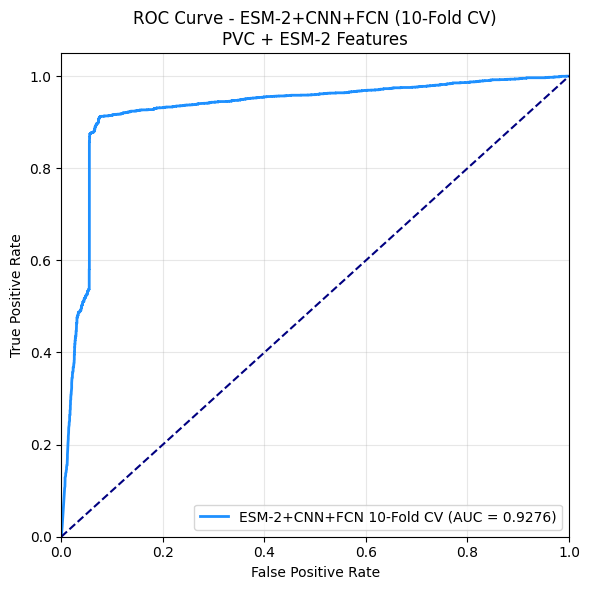


Saved: ESM_CNN_FCN_10Fold_Detailed_Folds.csv
Saved: ESM_CNN_FCN_10Fold_Results.csv
Saved: ROC_ESM_CNN_FCN_10Fold.png
Saved: roc_values_esm_cnn_fcn.npz


In [ ]:
"""
ESM-2 + CNN + FCN Model (10-Fold Cross-Validation)
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : Stratified 10-Fold Cross-Validation
Batch   : 32
Epochs  : 100 per fold
Outputs : Fold-wise & Mean Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + ROC curve variables: fpr_esm_cnn_fcn, tpr_esm_cnn_fcn, roc_auc_esm_cnn_fcn

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> Multi-kernel Conv1D Extractor (CNN)
                 -> Global Pooling & Projection
                 -> Deep Residual Fully Connected Network (FCN)
                 -> Binary Sigmoid Output
"""

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# ----------------------------------------------------------------------
# 0. Reproducibility
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling (stabilizes ESM-2 + PVC feature magnitudes)
X = np.arcsinh(X).astype("float32")

# ----------------------------------------------------------------------
# 2. ESM-2 + CNN + FCN Architecture
# ----------------------------------------------------------------------
class ESM_CNN_FCN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # --- CNN Front-End (Feature Extraction) ---
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, padding=3)
        self.bn1   = nn.BatchNorm1d(64)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(2)

        # --- CNN to FCN Bridge ---
        cnn_out_dim = 256 * 2  # Pooling (Mean + Max)

        # --- Deep FCN Back-End ---
        self.fcn_proj = nn.Linear(cnn_out_dim, 512)

        # Residual Block 1
        self.fcn_block1 = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512)
        )

        # Residual Block 2
        self.fcn_block2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256)
        )
        self.fcn_downsample = nn.Linear(512, 256)

        # Final Classification Output
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (batch_size, input_dim) -> reshape to 3D for Conv1d: (batch_size, 1, input_dim)
        x = x.unsqueeze(1)

        # CNN forward pass
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)

        # Dual Pooling (Mean + Max pooling)
        mean_pool = torch.mean(x, dim=2)
        max_pool  = torch.max(x, dim=2)[0]
        cnn_features = torch.cat([mean_pool, max_pool], dim=1)

        # FCN forward pass
        f1 = F.relu(self.fcn_proj(cnn_features))

        # FCN Residual Block 1
        res1 = f1 + self.fcn_block1(f1)
        res1 = F.relu(res1)

        # FCN Residual Block 2
        res2 = self.fcn_downsample(res1) + self.fcn_block2(res1)
        res2 = F.relu(res2)

        # Binary Classification Output
        logits = self.classifier(res2)
        return logits.squeeze(-1)


# ----------------------------------------------------------------------
# 3. Stratified 10-Fold Cross-Validation Setup
# ----------------------------------------------------------------------
N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics = []
oof_preds_prob = np.zeros(len(y))
oof_preds_class = np.zeros(len(y))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold     = X[val_idx], y[val_idx]

    # Feature scaling (fitted ONLY on training fold to prevent data leakage)
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    # Convert to PyTorch DataLoaders
    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.float32))
    val_dataset   = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Initialize Model, Loss, Optimizer
    model = ESM_CNN_FCN(input_dim=X.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    # Fold Training Loop
    epochs = 100
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)
        scheduler.step(train_loss)

    # Fold Evaluation
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    # Compute Fold Metrics
    tn, fp, fn, tp = confusion_matrix(y_val_fold, val_preds).ravel()
    acc  = accuracy_score(y_val_fold, val_preds)
    sens = recall_score(y_val_fold, val_preds)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_val_fold, val_preds, zero_division=0)
    f1   = f1_score(y_val_fold, val_preds)
    mcc  = matthews_corrcoef(y_val_fold, val_preds)
    auc_ = roc_auc_score(y_val_fold, val_probs)

    fold_metrics.append({
        "Fold": fold, "Accuracy": acc, "Sensitivity": sens,
        "Specificity": spec, "Precision": prec, "F1_score": f1,
        "MCC": mcc, "AUC": auc_
    })
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Accuracy: {acc*100:.2f}% | Sensitivity: {sens*100:.2f}% | Specificity: {spec*100:.2f}% | AUC: {auc_:.4f}")

# ----------------------------------------------------------------------
# 4. Overall Out-of-Fold (OOF) Metrics
# ----------------------------------------------------------------------
oof_tn, oof_fp, oof_fn, oof_tp = confusion_matrix(y, oof_preds_class).ravel()

overall_acc  = accuracy_score(y, oof_preds_class)
overall_sens = recall_score(y, oof_preds_class)
overall_spec = oof_tn / (oof_tn + oof_fp)
overall_prec = precision_score(y, oof_preds_class)
overall_f1   = f1_score(y, oof_preds_class)
overall_mcc  = matthews_corrcoef(y, oof_preds_class)
overall_auc  = roc_auc_score(y, oof_preds_prob)

print("\n================ Final 10-Fold CV Summary Results ================")
print(f"Overall Accuracy    : {overall_acc*100:.4f}%")
print(f"Overall Sensitivity : {overall_sens*100:.4f}%")
print(f"Overall Specificity : {overall_spec*100:.4f}%")
print(f"Overall Precision   : {overall_prec*100:.4f}%")
print(f"Overall F1-Score    : {overall_f1*100:.4f}%")
print(f"Overall MCC         : {overall_mcc:.4f}")
print(f"Overall AUC         : {overall_auc:.4f}")
print(f"OOF Confusion Matrix -> TN:{oof_tn} FP:{oof_fp} FN:{oof_fn} TP:{oof_tp}")
print("===================================================================")

# ----------------------------------------------------------------------
# 5. ROC Curve Plotting and Variable Export
# ----------------------------------------------------------------------
fpr_esm_cnn_fcn, tpr_esm_cnn_fcn, thresholds_esm_cnn_fcn = roc_curve(y, oof_preds_prob)
roc_auc_esm_cnn_fcn = auc(fpr_esm_cnn_fcn, tpr_esm_cnn_fcn)

plt.figure(figsize=(6, 6))
plt.plot(
    fpr_esm_cnn_fcn,
    tpr_esm_cnn_fcn,
    color="dodgerblue",
    lw=2,
    label=f"ESM-2+CNN+FCN 10-Fold CV (AUC = {roc_auc_esm_cnn_fcn:.4f})",
)
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ESM-2+CNN+FCN (10-Fold CV)\nPVC + ESM-2 Features")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_ESM_CNN_FCN_10Fold.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 6. Save Metrics & ROC Variables
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
df_folds.to_csv("ESM_CNN_FCN_10Fold_Detailed_Folds.csv", index=False)

df_overall = pd.DataFrame([{
    "Model": "ESM_CNN_FCN_10Fold_CV",
    "Accuracy": overall_acc,
    "Sensitivity": overall_sens,
    "Specificity": overall_spec,
    "Precision": overall_prec,
    "F1_score": overall_f1,
    "MCC": overall_mcc,
    "AUC": overall_auc,
    "TN": oof_tn, "FP": oof_fp, "FN": oof_fn, "TP": oof_tp,
}])
df_overall.to_csv("ESM_CNN_FCN_10Fold_Results.csv", index=False)

np.savez(
    "roc_values_esm_cnn_fcn.npz",
    fpr_esm_cnn_fcn=fpr_esm_cnn_fcn,
    tpr_esm_cnn_fcn=tpr_esm_cnn_fcn,
    roc_auc_esm_cnn_fcn=roc_auc_esm_cnn_fcn,
)

print("\nSaved: ESM_CNN_FCN_10Fold_Detailed_Folds.csv")
print("Saved: ESM_CNN_FCN_10Fold_Results.csv")
print("Saved: ROC_ESM_CNN_FCN_10Fold.png")
print("Saved: roc_values_esm_cnn_fcn.npz")

In [ ]:
!pip install causal-conv1d>=1.4.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation

In [ ]:
"""
ESM-2 + Mamba-2 + FCN Model — Complete Pipeline
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : 85/15 Holdout Split  ->  Stratified 10-Fold CV on the 85% (train_cv)
                                 ->  Final ensemble evaluation on the 15% held-out test set
Batch   : 32
Epochs  : up to 100 per fold, with early stopping on validation loss
Outputs : Fold-wise & Mean±Std Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + Held-out test set metrics (ensemble of 10 fold models)
          + ROC curve variables for both CV (OOF) and held-out test set

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> Patch Embedding (feature vector split into tokens)
                 -> Stacked Mamba-2 (SSM) Blocks
                 -> Global Pooling (Mean + Max over sequence)
                 -> Deep Residual Fully Connected Network (FCN)
                 -> Binary Sigmoid Output

REQUIREMENTS (run once in Colab, GPU runtime required):
    !pip install mamba-ssm causal-conv1d --no-build-isolation
    (mamba-ssm's CUDA kernels require an NVIDIA GPU; there is no CPU fallback.)
"""

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

from mamba_ssm import Mamba2

# ----------------------------------------------------------------------
# 0. Reproducibility
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type != "cuda":
    raise RuntimeError("Mamba-2 (mamba-ssm) requires a CUDA GPU. Switch the Colab runtime to GPU.")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling (stabilizes ESM-2 + PVC feature magnitudes)
X = np.arcsinh(X).astype("float32")

RAW_DIM = X.shape[1]

# ----------------------------------------------------------------------
# 2. Held-out Test Split (85% CV pool / 15% untouched test set)
# ----------------------------------------------------------------------
X_cv, X_test, y_cv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
print(f"\nCV pool  : {X_cv.shape},  Label counts: {np.bincount(y_cv)}")
print(f"Held-out : {X_test.shape}, Label counts: {np.bincount(y_test)}")
print("NOTE: X_test / y_test are NOT touched again until final evaluation (Section 6).")

# ----------------------------------------------------------------------
# 3. ESM-2 + Mamba-2 + FCN Architecture
# ----------------------------------------------------------------------
# The 1D feature vector (e.g. 1433-dim) is split into non-overlapping
# "patches" of size PATCH_SIZE, each linearly embedded into d_model —
# turning the flat feature vector into a short token sequence that
# Mamba-2's selective state-space blocks can scan over.
PATCH_SIZE = 16
D_MODEL    = 128
N_LAYERS   = 4
D_STATE    = 64
D_CONV     = 4
EXPAND     = 2
HEADDIM    = 64   # D_MODEL * EXPAND must be divisible by HEADDIM


class Mamba2Block(nn.Module):
    """Pre-norm residual wrapper around a single Mamba-2 layer."""
    def __init__(self, d_model):
        super().__init__()
        self.norm  = nn.LayerNorm(d_model)
        self.mamba = Mamba2(
            d_model=d_model,
            d_state=D_STATE,
            d_conv=D_CONV,
            expand=EXPAND,
            headdim=HEADDIM,
        )

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.mamba(self.norm(x))


class ESM_Mamba2_FCN(nn.Module):
    def __init__(self, input_dim, patch_size=PATCH_SIZE, d_model=D_MODEL, n_layers=N_LAYERS):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (input_dim + patch_size - 1) // patch_size
        self.padded_dim = self.n_patches * patch_size

        # --- Patch Embedding (tokenizes the flat feature vector) ---
        self.patch_embed = nn.Linear(patch_size, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # --- Stacked Mamba-2 (SSM) Blocks ---
        self.mamba_blocks = nn.ModuleList([Mamba2Block(d_model) for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model)

        # --- Mamba to FCN Bridge ---
        ssm_out_dim = d_model * 2  # Pooling (Mean + Max)

        # --- Deep FCN Back-End ---
        self.fcn_proj = nn.Linear(ssm_out_dim, 512)

        # Residual Block 1
        self.fcn_block1 = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512)
        )

        # Residual Block 2
        self.fcn_block2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256)
        )
        self.fcn_downsample = nn.Linear(512, 256)

        # Final Classification Output
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x: (batch_size, input_dim)
        batch_size = x.size(0)
        if self.padded_dim != x.size(1):
            pad = self.padded_dim - x.size(1)
            x = F.pad(x, (0, pad))

        # Tokenize: (batch, n_patches, patch_size)
        x = x.view(batch_size, self.n_patches, self.patch_size)
        x = self.patch_embed(x) + self.pos_embed  # (batch, n_patches, d_model)

        # Mamba-2 sequence scan
        for block in self.mamba_blocks:
            x = block(x)
        x = self.final_norm(x)

        # Dual Pooling (Mean + Max pooling over the sequence dimension)
        mean_pool = torch.mean(x, dim=1)
        max_pool  = torch.max(x, dim=1)[0]
        ssm_features = torch.cat([mean_pool, max_pool], dim=1)

        # FCN forward pass
        f1 = F.relu(self.fcn_proj(ssm_features))

        # FCN Residual Block 1
        res1 = f1 + self.fcn_block1(f1)
        res1 = F.relu(res1)

        # FCN Residual Block 2
        res2 = self.fcn_downsample(res1) + self.fcn_block2(res1)
        res2 = F.relu(res2)

        # Binary Classification Output
        logits = self.classifier(res2)
        return logits.squeeze(-1)


def compute_metrics(y_true, y_pred_class, y_pred_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    acc  = accuracy_score(y_true, y_pred_class)
    sens = recall_score(y_true, y_pred_class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred_class, zero_division=0)
    f1   = f1_score(y_true, y_pred_class)
    mcc  = matthews_corrcoef(y_true, y_pred_class)
    auc_ = roc_auc_score(y_true, y_pred_prob)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, F1_score=f1, MCC=mcc, AUC=auc_,
                TN=tn, FP=fp, FN=fn, TP=tp)


# ----------------------------------------------------------------------
# 4. Stratified 10-Fold Cross-Validation (on CV pool only)
# ----------------------------------------------------------------------
N_SPLITS   = 10
MAX_EPOCHS = 100
PATIENCE   = 10  # early stopping patience (epochs without val-loss improvement)

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics    = []
fold_models     = []   # trained model state_dicts, kept for test-set ensembling
fold_scalers    = []   # fitted scalers, kept for test-set ensembling
oof_preds_prob  = np.zeros(len(y_cv))
oof_preds_class = np.zeros(len(y_cv))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv, y_cv), 1):
    X_train_fold, y_train_fold = X_cv[train_idx], y_cv[train_idx]
    X_val_fold, y_val_fold     = X_cv[val_idx], y_cv[val_idx]

    # Feature scaling (fitted ONLY on training fold to prevent data leakage)
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    # Convert to PyTorch DataLoaders
    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.float32))
    val_dataset   = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Class-imbalance handling: weight the positive class in the loss
    n_pos = max((y_train_fold == 1).sum(), 1)
    n_neg = max((y_train_fold == 0).sum(), 1)
    pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)

    # Initialize Model, Loss, Optimizer
    model = ESM_Mamba2_FCN(input_dim=RAW_DIM).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val_loss = float("inf")
    best_state    = None
    epochs_no_improve = 0

    # Fold Training Loop with Early Stopping (on validation loss)
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation loss (unweighted BCE, for early stopping / scheduler)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = F.binary_cross_entropy_with_logits(logits, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Fold {fold:02d}: early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    # Restore best-epoch weights for this fold
    model.load_state_dict(best_state)
    fold_models.append(best_state)
    fold_scalers.append(scaler)

    # Fold Evaluation
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    m = compute_metrics(y_val_fold, val_preds, val_probs)
    m["Fold"] = fold
    fold_metrics.append(m)
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Acc: {m['Accuracy']*100:.2f}% | Sens: {m['Sensitivity']*100:.2f}% | "
          f"Spec: {m['Specificity']*100:.2f}% | F1: {m['F1_score']*100:.2f}% | MCC: {m['MCC']:.4f} | AUC: {m['AUC']:.4f}")

# ----------------------------------------------------------------------
# 5. CV Summary — Pooled OOF Metrics AND Mean ± Std Across Folds
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
metric_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]

mean_std_summary = pd.DataFrame({
    "Mean": df_folds[metric_cols].mean(),
    "Std":  df_folds[metric_cols].std()
})

oof_metrics = compute_metrics(y_cv, oof_preds_class, oof_preds_prob)

print("\n================ 10-Fold CV Summary (Mean ± Std across folds) ================")
for col in metric_cols:
    print(f"{col:12s}: {mean_std_summary.loc[col,'Mean']*100 if col!='MCC' else mean_std_summary.loc[col,'Mean']:.4f} "
          f"± {mean_std_summary.loc[col,'Std']*100 if col!='MCC' else mean_std_summary.loc[col,'Std']:.4f}"
          f"{'%' if col!='MCC' else ''}")

print("\n================ 10-Fold CV Summary (Pooled Out-of-Fold) ================")
for col in metric_cols:
    val = oof_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"OOF Confusion Matrix -> TN:{oof_metrics['TN']} FP:{oof_metrics['FP']} FN:{oof_metrics['FN']} TP:{oof_metrics['TP']}")
print("=================================================================================")

# ----------------------------------------------------------------------
# 6. Final Evaluation on the Untouched 15% Held-out Test Set
#    (ensemble = average predicted probability across the 10 fold models)
# ----------------------------------------------------------------------
print("\n================ Held-out Test Set Evaluation (10-model ensemble) ================")

test_probs_per_fold = np.zeros((N_SPLITS, len(y_test)))

for i, (state_dict, scaler) in enumerate(zip(fold_models, fold_scalers)):
    model = ESM_Mamba2_FCN(input_dim=RAW_DIM).to(device)
    model.load_state_dict(state_dict)
    model.eval()

    X_test_scaled = scaler.transform(X_test).astype("float32")
    test_dataset = TensorDataset(torch.tensor(X_test_scaled), torch.tensor(y_test, dtype=torch.float32))
    test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

    probs = []
    with torch.no_grad():
        for batch_X, _ in test_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
    test_probs_per_fold[i] = np.array(probs)

test_probs_ensemble = test_probs_per_fold.mean(axis=0)
test_preds_ensemble = (test_probs_ensemble >= 0.5).astype(int)

test_metrics = compute_metrics(y_test, test_preds_ensemble, test_probs_ensemble)

for col in metric_cols:
    val = test_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"Test Confusion Matrix -> TN:{test_metrics['TN']} FP:{test_metrics['FP']} FN:{test_metrics['FN']} TP:{test_metrics['TP']}")
print("=====================================================================================")

# ----------------------------------------------------------------------
# 7. ROC Curves — CV (OOF) and Held-out Test Set
# ----------------------------------------------------------------------
fpr_esm_mamba2_fcn, tpr_esm_mamba2_fcn, _ = roc_curve(y_cv, oof_preds_prob)
roc_auc_esm_mamba2_fcn = auc(fpr_esm_mamba2_fcn, tpr_esm_mamba2_fcn)

fpr_test_esm_mamba2_fcn, tpr_test_esm_mamba2_fcn, _ = roc_curve(y_test, test_probs_ensemble)
roc_auc_test_esm_mamba2_fcn = auc(fpr_test_esm_mamba2_fcn, tpr_test_esm_mamba2_fcn)

plt.figure(figsize=(6, 6))
plt.plot(fpr_esm_mamba2_fcn, tpr_esm_mamba2_fcn, color="dodgerblue", lw=2,
         label=f"10-Fold CV, OOF (AUC = {roc_auc_esm_mamba2_fcn:.4f})")
plt.plot(fpr_test_esm_mamba2_fcn, tpr_test_esm_mamba2_fcn, color="darkorange", lw=2,
         label=f"Held-out Test (AUC = {roc_auc_test_esm_mamba2_fcn:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ESM-2+Mamba-2+FCN\nPVC + ESM-2 Features")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_ESM_Mamba2_FCN.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 8. Save Metrics & ROC Variables
# ----------------------------------------------------------------------
df_folds.to_csv("ESM_Mamba2_FCN_10Fold_Detailed_Folds.csv", index=False)
mean_std_summary.to_csv("ESM_Mamba2_FCN_10Fold_MeanStd_Summary.csv")

df_overall = pd.DataFrame([
    {"Split": "CV_OOF", **oof_metrics},
    {"Split": "Held_out_Test", **test_metrics},
])
df_overall.to_csv("ESM_Mamba2_FCN_Overall_Results.csv", index=False)

np.savez(
    "roc_values_esm_mamba2_fcn.npz",
    fpr_esm_mamba2_fcn=fpr_esm_mamba2_fcn,
    tpr_esm_mamba2_fcn=tpr_esm_mamba2_fcn,
    roc_auc_esm_mamba2_fcn=roc_auc_esm_mamba2_fcn,
    fpr_test_esm_mamba2_fcn=fpr_test_esm_mamba2_fcn,
    tpr_test_esm_mamba2_fcn=tpr_test_esm_mamba2_fcn,
    roc_auc_test_esm_mamba2_fcn=roc_auc_test_esm_mamba2_fcn,
)

print("\nSaved: ESM_Mamba2_FCN_10Fold_Detailed_Folds.csv")
print("Saved: ESM_Mamba2_FCN_10Fold_MeanStd_Summary.csv")
print("Saved: ESM_Mamba2_FCN_Overall_Results.csv  (CV_OOF + Held_out_Test rows)")
print("Saved: ROC_ESM_Mamba2_FCN.png")
print("Saved: roc_values_esm_mamba2_fcn.npz")

In [ ]:
"""
Pure Kolmogorov–Arnold Network (KAN) — 10-Fold Cross-Validation Pipeline
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : Stratified 10-Fold Cross-Validation on 100% Data Pool
Batch   : 32
Epochs  : up to 100 per fold, with early stopping on validation loss
Outputs : Fold-wise & Mean±Std Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + ROC curve variables (fpr_kan, tpr_kan, roc_auc_kan)

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> KAN Layer 1 (Spline Transformation: input_dim -> 128)
                 -> LayerNorm & SiLU
                 -> KAN Layer 2 (Spline Transformation: 128 -> 64)
                 -> LayerNorm & SiLU
                 -> KAN Layer 3 (Output Head: 64 -> 1)
                 -> Binary Sigmoid Output
"""

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# ----------------------------------------------------------------------
# 0. Reproducibility & Device Setup
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling (stabilizes feature magnitudes)
X = np.arcsinh(X).astype("float32")
RAW_DIM = X.shape[1]

# ----------------------------------------------------------------------
# 2. Pure Kolmogorov-Arnold Network (KAN) Layer & Model Definition
# ----------------------------------------------------------------------
class KANLinear(nn.Module):
    """
    Fast B-Spline Kolmogorov-Arnold Network (KAN) Layer.
    Learns non-linear univariate activations via grid-based B-splines.
    """
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3, scale_noise=0.1, scale_base=1.0, scale_spline=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        # Base linear transformation
        self.base_weight = nn.Parameter(torch.Tensor(out_features, in_features))
        self.base_activation = nn.SiLU()

        # B-Spline grid & coefficients
        h = (1.0 - (-1.0)) / grid_size
        grid = (torch.arange(-spline_order, grid_size + spline_order + 1) * h - 1.0).expand(in_features, -1).contiguous()
        self.register_buffer("grid", grid)

        self.spline_weight = nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        self.scale_base = scale_base
        self.scale_spline = scale_spline

        # Parameter Initialization
        nn.init.kaiming_uniform_(self.base_weight, a=np.sqrt(5))
        with torch.no_grad():
            noise = (torch.rand(grid_size + spline_order, in_features, out_features) - 0.5) * scale_noise / grid_size
            self.spline_weight.copy_(noise.permute(2, 1, 0))

    def b_splines(self, x: torch.Tensor):
        x = x.unsqueeze(-1)
        grid = self.grid
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)]) / (grid[:, k:-1] - grid[:, : -(k + 1)]) * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x) / (grid[:, k + 1 :] - grid[:, 1:-k]) * bases[:, :, 1:]
            )
        return bases.contiguous()

    def forward(self, x: torch.Tensor):
        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_basis = self.b_splines(x)  # (batch_size, in_features, grid_size + spline_order)
        spline_output = torch.einsum("biq,oiq->bo", spline_basis, self.spline_weight)
        return self.scale_base * base_output + self.scale_spline * spline_output


class PureKAN(nn.Module):
    """
    Pure KAN Classifier consisting of stacked KANLinear spline layers.
    """
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, grid_size=5, spline_order=3):
        super().__init__()
        self.kan1 = KANLinear(input_dim, hidden_dim1, grid_size=grid_size, spline_order=spline_order)
        self.ln1  = nn.LayerNorm(hidden_dim1)

        self.kan2 = KANLinear(hidden_dim1, hidden_dim2, grid_size=grid_size, spline_order=spline_order)
        self.ln2  = nn.LayerNorm(hidden_dim2)

        self.kan_out = KANLinear(hidden_dim2, 1, grid_size=grid_size, spline_order=spline_order)

    def forward(self, x):
        x = self.kan1(x)
        x = F.silu(self.ln1(x))

        x = self.kan2(x)
        x = F.silu(self.ln2(x))

        logits = self.kan_out(x)
        return logits.squeeze(-1)


def compute_metrics(y_true, y_pred_class, y_pred_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    acc  = accuracy_score(y_true, y_pred_class)
    sens = recall_score(y_true, y_pred_class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred_class, zero_division=0)
    f1   = f1_score(y_true, y_pred_class)
    mcc  = matthews_corrcoef(y_true, y_pred_class)
    auc_ = roc_auc_score(y_true, y_pred_prob)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, F1_score=f1, MCC=mcc, AUC=auc_,
                TN=tn, FP=fp, FN=fn, TP=tp)

# ----------------------------------------------------------------------
# 3. Stratified 10-Fold Cross-Validation Loop
# ----------------------------------------------------------------------
N_SPLITS   = 10
MAX_EPOCHS = 100
PATIENCE   = 10  # early stopping patience

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics    = []
oof_preds_prob  = np.zeros(len(y))
oof_preds_class = np.zeros(len(y))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation (Pure KAN) ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold     = X[val_idx], y[val_idx]

    # Standard feature scaling per fold to prevent data leakage
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.float32))
    val_dataset   = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Class-imbalance weight
    n_pos = max((y_train_fold == 1).sum(), 1)
    n_neg = max((y_train_fold == 0).sum(), 1)
    pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)

    # Model, Optimizer, Loss Setup
    model = PureKAN(input_dim=RAW_DIM, hidden_dim1=128, hidden_dim2=64).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val_loss = float("inf")
    best_state    = None
    epochs_no_improve = 0

    # Training Loop
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = F.binary_cross_entropy_with_logits(logits, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Fold {fold:02d}: early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    # Restore best weights
    model.load_state_dict(best_state)

    # Evaluate Fold
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    m = compute_metrics(y_val_fold, val_preds, val_probs)
    m["Fold"] = fold
    fold_metrics.append(m)
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Acc: {m['Accuracy']*100:.2f}% | Sens: {m['Sensitivity']*100:.2f}% | "
          f"Spec: {m['Specificity']*100:.2f}% | Precision: {m['Precision']*100:.2f}% | F1: {m['F1_score']*100:.2f}% | MCC: {m['MCC']:.4f} | AUC: {m['AUC']:.4f}")

# ----------------------------------------------------------------------
# 4. Summary Statistics (Mean ± Std & Pooled Out-of-Fold)
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
metric_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]

mean_std_summary = pd.DataFrame({
    "Mean": df_folds[metric_cols].mean(),
    "Std":  df_folds[metric_cols].std()
})

oof_metrics = compute_metrics(y, oof_preds_class, oof_preds_prob)

print("\n================ Pure KAN 10-Fold CV Summary (Mean ± Std across folds) ================")
for col in metric_cols:
    print(f"{col:12s}: {mean_std_summary.loc[col,'Mean']*100 if col!='MCC' else mean_std_summary.loc[col,'Mean']:.4f} "
          f"± {mean_std_summary.loc[col,'Std']*100 if col!='MCC' else mean_std_summary.loc[col,'Std']:.4f}"
          f"{'%' if col!='MCC' else ''}")

print("\n================ Pure KAN 10-Fold CV Summary (Pooled Out-of-Fold) ================")
for col in metric_cols:
    val = oof_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"OOF Confusion Matrix -> TN:{oof_metrics['TN']} FP:{oof_metrics['FP']} FN:{oof_metrics['FN']} TP:{oof_metrics['TP']}")
print("=================================================================================")

# ----------------------------------------------------------------------
# 5. ROC Curve Generation & File Export
# ----------------------------------------------------------------------
fpr_kan, tpr_kan, _ = roc_curve(y, oof_preds_prob)
roc_auc_kan = auc(fpr_kan, tpr_kan)

plt.figure(figsize=(6, 6))
plt.plot(fpr_kan, tpr_kan, color="mediumpurple", lw=2,
         label=f"Pure KAN 10-Fold CV (AUC = {roc_auc_kan:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Pure Kolmogorov-Arnold Network (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_Pure_KAN_10Fold.png", dpi=300)
plt.show()

# Save metrics and variables
df_folds.to_csv("Pure_KAN_10Fold_Detailed_Folds.csv", index=False)
mean_std_summary.to_csv("Pure_KAN_10Fold_MeanStd_Summary.csv")

df_overall = pd.DataFrame([{"Model": "Pure_KAN_10Fold_CV", **oof_metrics}])
df_overall.to_csv("Pure_KAN_10Fold_Results.csv", index=False)

np.savez(
    "roc_values_pure_kan.npz",
    fpr_kan=fpr_kan,
    tpr_kan=tpr_kan,
    roc_auc_kan=roc_auc_kan,
)

print("\nSaved: Pure_KAN_10Fold_Detailed_Folds.csv")
print("Saved: Pure_KAN_10Fold_MeanStd_Summary.csv")
print("Saved: Pure_KAN_10Fold_Results.csv")
print("Saved: ROC_Pure_KAN_10Fold.png")
print("Saved: roc_values_pure_kan.npz")

In [ ]:
"""
Capsule Hybrid Network — 10-Fold Cross-Validation Pipeline
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : Stratified 10-Fold Cross-Validation on 100% Data Pool
Batch   : 32
Epochs  : up to 100 per fold, with early stopping on validation loss
Outputs : Fold-wise & Mean±Std Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + ROC curve variables (fpr_capsule, tpr_capsule, roc_auc_capsule)

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> Multi-kernel Conv1D Front-End (Feature Extraction)
                 -> Primary Capsule Layer (Groups Conv Features into Vectors)
                 -> Dynamic Routing Class Capsule Layer (Routings=3)
                 -> Capsule Length Softmax Head
"""

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# ----------------------------------------------------------------------
# 0. Reproducibility & Device Setup
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling (stabilizes high dynamic range features)
X = np.arcsinh(X).astype("float32")
RAW_DIM = X.shape[1]

# ----------------------------------------------------------------------
# 2. Capsule Network Building Blocks
# ----------------------------------------------------------------------
def squash(s, dim=-1, epsilon=1e-7):
    """Squashing activation bounds capsule vector length to [0, 1)."""
    s_squared_norm = torch.sum(s ** 2, dim=dim, keepdim=True)
    scale = s_squared_norm / (1.0 + s_squared_norm) / (torch.sqrt(s_squared_norm) + epsilon)
    return scale * s


class PrimaryCapsule(nn.Module):
    """Reshapes 1D Convolutional features into vector capsules."""
    def __init__(self, in_channels, num_channels, dim_capsule, kernel_size=3, stride=2):
        super().__init__()
        self.num_channels = num_channels
        self.dim_capsule = dim_capsule
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=num_channels * dim_capsule,
            kernel_size=kernel_size,
            stride=stride,
            padding=kernel_size // 2
        )

    def forward(self, x):
        # x shape: (batch_size, in_channels, seq_len)
        x = self.conv(x)
        # Reshape to (batch_size, total_capsules, dim_capsule)
        batch_size, _, seq_len = x.shape
        x = x.view(batch_size, self.num_channels, self.dim_capsule, seq_len)
        x = x.permute(0, 1, 3, 2).contiguous().view(batch_size, -1, self.dim_capsule)
        return squash(x)


class CapsuleRoutingLayer(nn.Module):
    """Class Capsule Layer with dynamic routing-by-agreement."""
    def __init__(self, in_capsules, in_dim, num_capsules=2, out_dim=32, routings=3):
        super().__init__()
        self.in_capsules = in_capsules
        self.in_dim = in_dim
        self.num_capsules = num_capsules
        self.out_dim = out_dim
        self.routings = routings

        # Transformation weight matrix W: (1, in_capsules, num_capsules, out_dim, in_dim)
        self.W = nn.Parameter(torch.randn(1, in_capsules, num_capsules, out_dim, in_dim) * 0.05)

    def forward(self, x):
        batch_size = x.size(0)

        # x shape: (batch_size, in_capsules, in_dim) -> Expand for multiplication
        x_expanded = x.unsqueeze(2).unsqueeze(3)  # (batch_size, in_capsules, 1, 1, in_dim)
        x_expanded = x_expanded.repeat(1, 1, self.num_capsules, 1, 1)

        W_expanded = self.W.repeat(batch_size, 1, 1, 1, 1)

        # Compute u_hat: (batch_size, in_capsules, num_capsules, out_dim)
        u_hat = torch.matmul(W_expanded, x_expanded.transpose(-1, -2)).squeeze(-1)

        # Dynamic routing
        b = torch.zeros(batch_size, self.in_capsules, self.num_capsules, 1, device=x.device)

        for r in range(self.routings):
            c = F.softmax(b, dim=2)  # Softmax over output capsules dimension
            # Weighted sum over input capsules
            s = torch.sum(c * u_hat, dim=1, keepdim=True)  # (batch_size, 1, num_capsules, out_dim)
            v = squash(s, dim=-1)

            if r < self.routings - 1:
                # Agreement update: Dot product between u_hat and v
                v_expanded = v.repeat(1, self.in_capsules, 1, 1)
                agreement = torch.matmul(u_hat.unsqueeze(-2), v_expanded.unsqueeze(-1)).squeeze(-1)
                b = b + agreement

        return v.squeeze(1)  # (batch_size, num_capsules, out_dim)


class CapsuleHybridNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # CNN Front-End Feature Extraction
        self.conv1 = nn.Conv1d(1, 128, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(128)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(128, 256, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(256)
        self.pool2 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(256, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)

        # Calculate feature map length after pooling
        conv_out_len = input_dim // 4

        # Primary Capsule Setup
        self.primary_caps = PrimaryCapsule(in_channels=256, num_channels=32, dim_capsule=16, kernel_size=3, stride=2)
        in_capsules = 32 * (conv_out_len // 2)

        # Class Capsule Routing Layer
        self.digit_caps = CapsuleRoutingLayer(in_capsules=in_capsules, in_dim=16, num_capsules=2, out_dim=32, routings=3)

    def forward(self, x):
        # Reshape input for 1D CNN: (batch_size, 1, input_dim)
        x = x.unsqueeze(1)

        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        x = F.relu(self.bn3(self.conv3(x)))

        x = self.primary_caps(x)
        x = self.digit_caps(x)

        # Calculate capsule length (vector magnitude) as output probabilities
        lengths = torch.sqrt(torch.sum(x ** 2, dim=-1) + 1e-7)  # (batch_size, 2)
        return lengths


def compute_metrics(y_true, y_pred_class, y_pred_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    acc  = accuracy_score(y_true, y_pred_class)
    sens = recall_score(y_true, y_pred_class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred_class, zero_division=0)
    f1   = f1_score(y_true, y_pred_class)
    mcc  = matthews_corrcoef(y_true, y_pred_class)
    auc_ = roc_auc_score(y_true, y_pred_prob)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, F1_score=f1, MCC=mcc, AUC=auc_,
                TN=tn, FP=fp, FN=fn, TP=tp)

# ----------------------------------------------------------------------
# 3. Stratified 10-Fold Cross-Validation Loop
# ----------------------------------------------------------------------
N_SPLITS   = 10
MAX_EPOCHS = 100
PATIENCE   = 10  # early stopping patience

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics    = []
oof_preds_prob  = np.zeros(len(y))
oof_preds_class = np.zeros(len(y))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation (Capsule Hybrid) ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold     = X[val_idx], y[val_idx]

    # Standard feature scaling per fold to prevent data leakage
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.long))
    val_dataset   = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold, dtype=torch.long))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Initialize Model, Criterion, Optimizer
    model = CapsuleHybridNetwork(input_dim=RAW_DIM).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val_loss = float("inf")
    best_state    = None
    epochs_no_improve = 0

    # Training Loop
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            caps_lengths = model(batch_X)
            loss = criterion(caps_lengths, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                caps_lengths = model(batch_X)
                loss = criterion(caps_lengths, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Fold {fold:02d}: early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    # Restore best weights
    model.load_state_dict(best_state)

    # Evaluate Fold
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            caps_lengths = model(batch_X)
            probs = F.softmax(caps_lengths, dim=1)[:, 1]
            val_probs.extend(probs.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    m = compute_metrics(y_val_fold, val_preds, val_probs)
    m["Fold"] = fold
    fold_metrics.append(m)
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Acc: {m['Accuracy']*100:.2f}% | Sens: {m['Sensitivity']*100:.2f}% | "
          f"Spec: {m['Specificity']*100:.2f}% | Precision: {m['Precision']*100:.2f}% | F1: {m['F1_score']*100:.2f}% | MCC: {m['MCC']:.4f} | AUC: {m['AUC']:.4f}")

# ----------------------------------------------------------------------
# 4. Summary Statistics (Mean ± Std & Pooled Out-of-Fold)
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
metric_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]

mean_std_summary = pd.DataFrame({
    "Mean": df_folds[metric_cols].mean(),
    "Std":  df_folds[metric_cols].std()
})

oof_metrics = compute_metrics(y, oof_preds_class, oof_preds_prob)

print("\n================ Capsule Hybrid 10-Fold CV Summary (Mean ± Std across folds) ================")
for col in metric_cols:
    print(f"{col:12s}: {mean_std_summary.loc[col,'Mean']*100 if col!='MCC' else mean_std_summary.loc[col,'Mean']:.4f} "
          f"± {mean_std_summary.loc[col,'Std']*100 if col!='MCC' else mean_std_summary.loc[col,'Std']:.4f}"
          f"{'%' if col!='MCC' else ''}")

print("\n================ Capsule Hybrid 10-Fold CV Summary (Pooled Out-of-Fold) ================")
for col in metric_cols:
    val = oof_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"OOF Confusion Matrix -> TN:{oof_metrics['TN']} FP:{oof_metrics['FP']} FN:{oof_metrics['FN']} TP:{oof_metrics['TP']}")
print("=================================================================================")

# ----------------------------------------------------------------------
# 5. ROC Curve Generation & File Export
# ----------------------------------------------------------------------
fpr_capsule, tpr_capsule, _ = roc_curve(y, oof_preds_prob)
roc_auc_capsule = auc(fpr_capsule, tpr_capsule)

plt.figure(figsize=(6, 6))
plt.plot(fpr_capsule, tpr_capsule, color="crimson", lw=2,
         label=f"Capsule Hybrid 10-Fold CV (AUC = {roc_auc_capsule:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Capsule Hybrid Network (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_Capsule_Hybrid_10Fold.png", dpi=300)
plt.show()

# Save metrics and ROC arrays
df_folds.to_csv("Capsule_Hybrid_10Fold_Detailed_Folds.csv", index=False)
mean_std_summary.to_csv("Capsule_Hybrid_10Fold_MeanStd_Summary.csv")

df_overall = pd.DataFrame([{"Model": "Capsule_Hybrid_10Fold_CV", **oof_metrics}])
df_overall.to_csv("Capsule_Hybrid_10Fold_Results.csv", index=False)

np.savez(
    "roc_values_capsule.npz",
    fpr_capsule=fpr_capsule,
    tpr_capsule=tpr_capsule,
    roc_auc_capsule=roc_auc_capsule,
)

print("\nSaved: Capsule_Hybrid_10Fold_Detailed_Folds.csv")
print("Saved: Capsule_Hybrid_10Fold_MeanStd_Summary.csv")
print("Saved: Capsule_Hybrid_10Fold_Results.csv")
print("Saved: ROC_Capsule_Hybrid_10Fold.png")
print("Saved: roc_values_capsule.npz")

In [ ]:
"""
Siamese Contrastive Network — 10-Fold Cross-Validation Pipeline
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : Stratified 10-Fold Cross-Validation on 100% Data Pool
Batch   : 32
Epochs  : up to 100 per fold, with early stopping on validation loss
Outputs : Fold-wise & Mean±Std Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + ROC curve variables (fpr_siamese, tpr_siamese, roc_auc_siamese)

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> Siamese Twin Encoders (Feature projection to L2-normalized metric space)
                 -> Contrastive Loss Optimization (Margin-based Distance Learning)
                 -> Centroid Distance Classifier -> Sigmoid Probabilities
"""

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# ----------------------------------------------------------------------
# 0. Reproducibility & Device Setup
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling
X = np.arcsinh(X).astype("float32")
RAW_DIM = X.shape[1]

# ----------------------------------------------------------------------
# 2. Siamese Dataset & Contrastive Loss Definition
# ----------------------------------------------------------------------
class SiamesePairDataset(Dataset):
    """Generates pairs of samples for Contrastive Learning."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.num_samples = len(y)

        # Group indices by class for pair generation
        self.label_to_indices = {
            label: np.where(y == label)[0] for label in np.unique(y)
        }

    def __getitem__(self, index):
        x1 = self.X[index]
        y1 = self.y[index].item()

        # 50% chance of positive pair (same class), 50% chance of negative pair
        same_class = random.random() > 0.5
        if same_class:
            idx2 = random.choice(self.label_to_indices[y1])
        else:
            different_label = random.choice([l for l in self.label_to_indices.keys() if l != y1])
            idx2 = random.choice(self.label_to_indices[different_label])

        x2 = self.X[idx2]
        y2 = self.y[idx2].item()

        # target_label = 1 if same class, 0 if different class
        target_label = torch.tensor(1.0 if y1 == y2 else 0.0, dtype=torch.float32)
        return x1, x2, target_label

    def __len__(self):
        return self.num_samples


class ContrastiveLoss(nn.Module):
    """Contrastive Loss function based on Euclidean distance."""
    def __init__(self, margin=2.0):
        super().__init__()
        self.margin = margin

    def forward(self, embedding1, embedding2, target):
        euclidean_distance = F.pairwise_distance(embedding1, embedding2)

        # Same class: minimize distance | Different class: maximize distance up to margin
        loss_contrastive = torch.mean(
            target * torch.pow(euclidean_distance, 2) +
            (1 - target) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2)
        )
        return loss_contrastive


class SiameseEncoder(nn.Module):
    """Deep Feature Encoder mapping input vectors to an L2-normalized embedding space."""
    def __init__(self, input_dim, embedding_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        # L2 normalize embeddings onto a unit hypersphere
        return F.normalize(embeddings, p=2, dim=1)


def compute_metrics(y_true, y_pred_class, y_pred_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    acc  = accuracy_score(y_true, y_pred_class)
    sens = recall_score(y_true, y_pred_class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred_class, zero_division=0)
    f1   = f1_score(y_true, y_pred_class)
    mcc  = matthews_corrcoef(y_true, y_pred_class)
    auc_ = roc_auc_score(y_true, y_pred_prob)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, F1_score=f1, MCC=mcc, AUC=auc_,
                TN=tn, FP=fp, FN=fn, TP=tp)

# ----------------------------------------------------------------------
# 3. Stratified 10-Fold Cross-Validation Loop
# ----------------------------------------------------------------------
N_SPLITS   = 10
MAX_EPOCHS = 100
PATIENCE   = 10  # early stopping patience

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics    = []
oof_preds_prob  = np.zeros(len(y))
oof_preds_class = np.zeros(len(y))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation (Siamese Contrastive) ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold     = X[val_idx], y[val_idx]

    # Standard feature scaling per fold to prevent data leakage
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    train_dataset = SiamesePairDataset(X_train_fold, y_train_fold)
    val_dataset   = SiamesePairDataset(X_val_fold, y_val_fold)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Initialize Siamese Model, Loss, Optimizer
    model = SiameseEncoder(input_dim=RAW_DIM, embedding_dim=128).to(device)
    criterion = ContrastiveLoss(margin=2.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val_loss = float("inf")
    best_state    = None
    epochs_no_improve = 0

    # Training Loop
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for x1, x2, targets in train_loader:
            x1, x2, targets = x1.to(device), x2.to(device), targets.to(device)

            optimizer.zero_grad()
            emb1 = model(x1)
            emb2 = model(x2)
            loss = criterion(emb1, emb2, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * x1.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x1, x2, targets in val_loader:
                x1, x2, targets = x1.to(device), x2.to(device), targets.to(device)
                emb1 = model(x1)
                emb2 = model(x2)
                loss = criterion(emb1, emb2, targets)
                val_loss += loss.item() * x1.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Fold {fold:02d}: early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    # Restore best weights
    model.load_state_dict(best_state)
    model.eval()

    # Calculate Class Centroids in Embedding Space using training fold embeddings
    with torch.no_grad():
        X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32).to(device)
        train_embeddings = model(X_train_tensor)

        centroid_0 = train_embeddings[y_train_fold == 0].mean(dim=0, keepdim=True)
        centroid_1 = train_embeddings[y_train_fold == 1].mean(dim=0, keepdim=True)

    # Evaluate Fold Validation Set based on distance to Centroid 1 vs Centroid 0
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32).to(device)
        val_embeddings = model(X_val_tensor)

        dist_0 = F.pairwise_distance(val_embeddings, centroid_0)
        dist_1 = F.pairwise_distance(val_embeddings, centroid_1)

        # Convert distance difference to probabilities using sigmoid
        distance_diff = dist_0 - dist_1  # positive if closer to centroid_1
        val_probs = torch.sigmoid(distance_diff).cpu().numpy()

    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    m = compute_metrics(y_val_fold, val_preds, val_probs)
    m["Fold"] = fold
    fold_metrics.append(m)
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Acc: {m['Accuracy']*100:.2f}% | Sens: {m['Sensitivity']*100:.2f}% | "
          f"Spec: {m['Specificity']*100:.2f}% | Precision: {m['Precision']*100:.2f}% | F1: {m['F1_score']*100:.2f}% | MCC: {m['MCC']:.4f} | AUC: {m['AUC']:.4f}")

# ----------------------------------------------------------------------
# 4. Summary Statistics (Mean ± Std & Pooled Out-of-Fold)
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
metric_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]

mean_std_summary = pd.DataFrame({
    "Mean": df_folds[metric_cols].mean(),
    "Std":  df_folds[metric_cols].std()
})

oof_metrics = compute_metrics(y, oof_preds_class, oof_preds_prob)

print("\n================ Siamese Contrastive 10-Fold CV Summary (Mean ± Std across folds) ================")
for col in metric_cols:
    print(f"{col:12s}: {mean_std_summary.loc[col,'Mean']*100 if col!='MCC' else mean_std_summary.loc[col,'Mean']:.4f} "
          f"± {mean_std_summary.loc[col,'Std']*100 if col!='MCC' else mean_std_summary.loc[col,'Std']:.4f}"
          f"{'%' if col!='MCC' else ''}")

print("\n================ Siamese Contrastive 10-Fold CV Summary (Pooled Out-of-Fold) ================")
for col in metric_cols:
    val = oof_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"OOF Confusion Matrix -> TN:{oof_metrics['TN']} FP:{oof_metrics['FP']} FN:{oof_metrics['FN']} TP:{oof_metrics['TP']}")
print("=================================================================================")

# ----------------------------------------------------------------------
# 5. ROC Curve Generation & File Export
# ----------------------------------------------------------------------
fpr_siamese, tpr_siamese, _ = roc_curve(y, oof_preds_prob)
roc_auc_siamese = auc(fpr_siamese, tpr_siamese)

plt.figure(figsize=(6, 6))
plt.plot(fpr_siamese, tpr_siamese, color="teal", lw=2,
         label=f"Siamese Contrastive 10-Fold CV (AUC = {roc_auc_siamese:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Siamese Contrastive Network (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_Siamese_Contrastive_10Fold.png", dpi=300)
plt.show()

# Save metrics and ROC arrays
df_folds.to_csv("Siamese_Contrastive_10Fold_Detailed_Folds.csv", index=False)
mean_std_summary.to_csv("Siamese_Contrastive_10Fold_MeanStd_Summary.csv")

df_overall = pd.DataFrame([{"Model": "Siamese_Contrastive_10Fold_CV", **oof_metrics}])
df_overall.to_csv("Siamese_Contrastive_10Fold_Results.csv", index=False)

np.savez(
    "roc_values_siamese.npz",
    fpr_siamese=fpr_siamese,
    tpr_siamese=tpr_siamese,
    roc_auc_siamese=roc_auc_siamese,
)

print("\nSaved: Siamese_Contrastive_10Fold_Detailed_Folds.csv")
print("Saved: Siamese_Contrastive_10Fold_MeanStd_Summary.csv")
print("Saved: Siamese_Contrastive_10Fold_Results.csv")
print("Saved: ROC_Siamese_Contrastive_10Fold.png")
print("Saved: roc_values_siamese.npz")

In [ ]:
"""
xLSTM (Extended LSTM with Matrix Memory) — 10-Fold Cross-Validation Pipeline
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Method  : Stratified 10-Fold Cross-Validation on 100% Data Pool
Batch   : 32
Epochs  : up to 100 per fold, with early stopping on validation loss
Outputs : Fold-wise & Mean±Std Accuracy, Sensitivity, Specificity, Precision, F1, MCC, AUC
          + ROC curve variables (fpr_xlstm, tpr_xlstm, roc_auc_xlstm)

Architecture:
    raw features -> Arcsinh Scaling & StandardScaler (per fold)
                 -> Patch Sequence Tokenizer (Feature vector split into sequence)
                 -> xLSTM Block (Matrix Memory mLSTM with Exponential Gating)
                 -> Global Dual Pooling (Mean + Max over sequence)
                 -> Classification Head -> Sigmoid Probability Output
"""

import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             roc_curve, auc, roc_auc_score)

# ----------------------------------------------------------------------
# 0. Reproducibility & Device Setup
# ----------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ----------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------
DATA_PATH = "/content/GulcoMetabolismESM2_650M_1280Dver27.csv"  # update path if needed
df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Label"]
X = df[feature_cols].values.astype("float64")
y = df["Label"].values.astype("int64")

print(f"Feature matrix : {X.shape}")
print(f"Label counts   : {np.bincount(y)}")

# Defensive NaN/inf handling
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Arcsinh dynamic-range scaling
X = np.arcsinh(X).astype("float32")
RAW_DIM = X.shape[1]

# ----------------------------------------------------------------------
# 2. xLSTM Architecture (mLSTM Matrix Memory Layer)
# ----------------------------------------------------------------------
class mLSTMLayer(nn.Module):
    """
    Matrix LSTM (mLSTM) core block from the xLSTM architecture.
    Uses covariance-style outer-product matrix updates for hidden memory C,
    along with exponential input/forget gating for enhanced capacity.
    """
    def __init__(self, d_model, key_dim=32, value_dim=32):
        super().__init__()
        self.d_model = d_model
        self.key_dim = key_dim
        self.value_dim = value_dim

        # Projections for Key, Value, Query, and Gates
        self.q_proj = nn.Linear(d_model, key_dim)
        self.k_proj = nn.Linear(d_model, key_dim)
        self.v_proj = nn.Linear(d_model, value_dim)

        self.i_gate = nn.Linear(d_model, 1)  # Input gate
        self.f_gate = nn.Linear(d_model, 1)  # Forget gate
        self.o_gate = nn.Linear(d_model, d_model)  # Output gate

        self.out_proj = nn.Linear(value_dim, d_model)
        self.ln = nn.LayerNorm(d_model)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, _ = x.shape

        q = self.q_proj(x)  # (batch, seq_len, key_dim)
        k = self.k_proj(x)  # (batch, seq_len, key_dim)
        v = self.v_proj(x)  # (batch, seq_len, value_dim)

        # Exponential gating values
        i = torch.exp(torch.clamp(self.i_gate(x), max=10.0))  # (batch, seq_len, 1)
        f = torch.sigmoid(self.f_gate(x))                      # (batch, seq_len, 1)
        o = torch.sigmoid(self.o_gate(x))                      # (batch, seq_len, d_model)

        # Initialize Matrix Memory C (key_dim x value_dim) and normalizer n
        C = torch.zeros(batch_size, self.key_dim, self.value_dim, device=x.device)
        n = torch.zeros(batch_size, self.key_dim, 1, device=x.device)

        outputs = []
        for t in range(seq_len):
            q_t = q[:, t:t+1, :]  # (batch, 1, key_dim)
            k_t = k[:, t:t+1, :]  # (batch, 1, key_dim)
            v_t = v[:, t:t+1, :]  # (batch, 1, value_dim)

            i_t = i[:, t:t+1, :]  # (batch, 1, 1)
            f_t = f[:, t:t+1, :]  # (batch, 1, 1)

            # Outer product update for Matrix Memory: C_t = f_t * C_{t-1} + i_t * (k_t^T x v_t)
            kv_outer = torch.matmul(k_t.transpose(1, 2), v_t)  # (batch, key_dim, value_dim)
            C = f_t * C + i_t * kv_outer

            # Update normalizer vector
            n = f_t * n + i_t * k_t.transpose(1, 2)

            # Memory retrieval via Query vector
            # h_raw = (q_t x C) / max(|q_t x n|, eps)
            num = torch.matmul(q_t, C)  # (batch, 1, value_dim)
            den = torch.abs(torch.matmul(q_t, n)) + 1e-6
            h_raw = num / den

            outputs.append(h_raw)

        h_seq = torch.cat(outputs, dim=1)  # (batch, seq_len, value_dim)
        h_out = o * self.out_proj(h_seq)   # Apply output gate
        return self.ln(x + h_out)


class xLSTMClassifier(nn.Module):
    def __init__(self, input_dim, patch_size=16, d_model=128, n_layers=2):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (input_dim + patch_size - 1) // patch_size
        self.padded_dim = self.n_patches * patch_size

        # Patch Embedding
        self.patch_embed = nn.Linear(patch_size, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # Stacked mLSTM Blocks
        self.xlstm_layers = nn.ModuleList([
            mLSTMLayer(d_model=d_model, key_dim=32, value_dim=32) for _ in range(n_layers)
        ])

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        batch_size = x.size(0)
        if self.padded_dim != x.size(1):
            pad = self.padded_dim - x.size(1)
            x = F.pad(x, (0, pad))

        # Tokenize flat feature vector into patches
        x = x.view(batch_size, self.n_patches, self.patch_size)
        x = self.patch_embed(x) + self.pos_embed

        # xLSTM Processing
        for layer in self.xlstm_layers:
            x = layer(x)

        # Global Dual Pooling (Mean + Max pooling over token sequence)
        mean_pool = torch.mean(x, dim=1)
        max_pool  = torch.max(x, dim=1)[0]
        pooled = torch.cat([mean_pool, max_pool], dim=1)

        logits = self.classifier(pooled)
        return logits.squeeze(-1)


def compute_metrics(y_true, y_pred_class, y_pred_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    acc  = accuracy_score(y_true, y_pred_class)
    sens = recall_score(y_true, y_pred_class)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    prec = precision_score(y_true, y_pred_class, zero_division=0)
    f1   = f1_score(y_true, y_pred_class)
    mcc  = matthews_corrcoef(y_true, y_pred_class)
    auc_ = roc_auc_score(y_true, y_pred_prob)
    return dict(Accuracy=acc, Sensitivity=sens, Specificity=spec,
                Precision=prec, F1_score=f1, MCC=mcc, AUC=auc_,
                TN=tn, FP=fp, FN=fn, TP=tp)

# ----------------------------------------------------------------------
# 3. Stratified 10-Fold Cross-Validation Loop
# ----------------------------------------------------------------------
N_SPLITS   = 10
MAX_EPOCHS = 100
PATIENCE   = 10  # early stopping patience

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_metrics    = []
oof_preds_prob  = np.zeros(len(y))
oof_preds_class = np.zeros(len(y))

print(f"\n================ Starting {N_SPLITS}-Fold Cross-Validation (xLSTM / mLSTM) ================")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, y_train_fold = X[train_idx], y[train_idx]
    X_val_fold, y_val_fold     = X[val_idx], y[val_idx]

    # Standard feature scaling per fold to prevent data leakage
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype("float32")
    X_val_fold   = scaler.transform(X_val_fold).astype("float32")

    train_dataset = TensorDataset(torch.tensor(X_train_fold), torch.tensor(y_train_fold, dtype=torch.float32))
    val_dataset   = TensorDataset(torch.tensor(X_val_fold), torch.tensor(y_val_fold, dtype=torch.float32))

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=256, shuffle=False)

    # Class-imbalance weighting
    n_pos = max((y_train_fold == 1).sum(), 1)
    n_neg = max((y_train_fold == 0).sum(), 1)
    pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32).to(device)

    # Model, Optimizer, Scheduler Setup
    model = xLSTMClassifier(input_dim=RAW_DIM, patch_size=16, d_model=128, n_layers=2).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)

    best_val_loss = float("inf")
    best_state    = None
    epochs_no_improve = 0

    # Training Loop
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item() * batch_X.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation Loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                logits = model(batch_X)
                loss = F.binary_cross_entropy_with_logits(logits, batch_y)
                val_loss += loss.item() * batch_X.size(0)
        val_loss /= len(val_loader.dataset)

        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Fold {fold:02d}: early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")
                break

    # Restore best weights
    model.load_state_dict(best_state)

    # Evaluate Fold Validation Set
    model.eval()
    val_probs = []
    with torch.no_grad():
        for batch_X, _ in val_loader:
            batch_X = batch_X.to(device)
            logits = model(batch_X)
            probs = torch.sigmoid(logits)
            val_probs.extend(probs.cpu().numpy())

    val_probs = np.array(val_probs)
    val_preds = (val_probs >= 0.5).astype(int)

    oof_preds_prob[val_idx]  = val_probs
    oof_preds_class[val_idx] = val_preds

    m = compute_metrics(y_val_fold, val_preds, val_probs)
    m["Fold"] = fold
    fold_metrics.append(m)
    print(f"Fold {fold:02d}/{N_SPLITS:02d} | Acc: {m['Accuracy']*100:.2f}% | Sens: {m['Sensitivity']*100:.2f}% | "
          f"Spec: {m['Specificity']*100:.2f}% | Precision: {m['Precision']*100:.2f}% | F1: {m['F1_score']*100:.2f}% | MCC: {m['MCC']:.4f} | AUC: {m['AUC']:.4f}")

# ----------------------------------------------------------------------
# 4. Summary Statistics (Mean ± Std & Pooled Out-of-Fold)
# ----------------------------------------------------------------------
df_folds = pd.DataFrame(fold_metrics)
metric_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]

mean_std_summary = pd.DataFrame({
    "Mean": df_folds[metric_cols].mean(),
    "Std":  df_folds[metric_cols].std()
})

oof_metrics = compute_metrics(y, oof_preds_class, oof_preds_prob)

print("\n================ xLSTM 10-Fold CV Summary (Mean ± Std across folds) ================")
for col in metric_cols:
    print(f"{col:12s}: {mean_std_summary.loc[col,'Mean']*100 if col!='MCC' else mean_std_summary.loc[col,'Mean']:.4f} "
          f"± {mean_std_summary.loc[col,'Std']*100 if col!='MCC' else mean_std_summary.loc[col,'Std']:.4f}"
          f"{'%' if col!='MCC' else ''}")

print("\n================ xLSTM 10-Fold CV Summary (Pooled Out-of-Fold) ================")
for col in metric_cols:
    val = oof_metrics[col]
    print(f"{col:12s}: {val*100 if col!='MCC' else val:.4f}{'%' if col!='MCC' else ''}")
print(f"OOF Confusion Matrix -> TN:{oof_metrics['TN']} FP:{oof_metrics['FP']} FN:{oof_metrics['FN']} TP:{oof_metrics['TP']}")
print("=================================================================================")

# ----------------------------------------------------------------------
# 5. ROC Curve Generation & File Export
# ----------------------------------------------------------------------
fpr_xlstm, tpr_xlstm, _ = roc_curve(y, oof_preds_prob)
roc_auc_xlstm = auc(fpr_xlstm, tpr_xlstm)

plt.figure(figsize=(6, 6))
plt.plot(fpr_xlstm, tpr_xlstm, color="forestgreen", lw=2,
         label=f"xLSTM 10-Fold CV (AUC = {roc_auc_xlstm:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - xLSTM Network (10-Fold CV)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_xLSTM_10Fold.png", dpi=300)
plt.show()

# Save metrics and ROC arrays
df_folds.to_csv("xLSTM_10Fold_Detailed_Folds.csv", index=False)
mean_std_summary.to_csv("xLSTM_10Fold_MeanStd_Summary.csv")

df_overall = pd.DataFrame([{"Model": "xLSTM_10Fold_CV", **oof_metrics}])
df_overall.to_csv("xLSTM_10Fold_Results.csv", index=False)

np.savez(
    "roc_values_xlstm.npz",
    fpr_xlstm=fpr_xlstm,
    tpr_xlstm=tpr_xlstm,
    roc_auc_xlstm=roc_auc_xlstm,
)

print("\nSaved: xLSTM_10Fold_Detailed_Folds.csv")
print("Saved: xLSTM_10Fold_MeanStd_Summary.csv")
print("Saved: xLSTM_10Fold_Results.csv")
print("Saved: ROC_xLSTM_10Fold.png")
print("Saved: roc_values_xlstm.npz")

In [ ]:
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import auc
# ==========================================================
# FULL HD FIGURE
# ==========================================================

plt.figure(
    figsize=(8,8),
    dpi=300
)
plt.plot(
    fpr_cnntransformer,
    tpr_cnntransformer,
    color="darkorange",
    lw=2,
    label=f"CNN-Transformer (AUC = {roc_auc_cnntransformer:.4f})",
)

plt.plot(fpr_xlstm, tpr_xlstm, color="forestgreen", lw=2,
         label=f"xLSTM 10-Fold CV (AUC = {roc_auc_xlstm:.4f})")


plt.plot(
    fpr_mamba,
    tpr_mamba,
    color="purple",
    lw=2,
    label=f"Mamba-2 (AUC = {roc_auc_mamba:.4f})",
)

plt.plot(fpr_siamese, tpr_siamese, color="teal", lw=2,
         label=f"Siamese Contrastive 10-Fold CV (AUC = {roc_auc_siamese:.4f})")

plt.plot(fpr_capsule, tpr_capsule, color="crimson", lw=2,
         label=f"Capsule Hybrid 10-Fold CV (AUC = {roc_auc_capsule:.4f})")


plt.plot(fpr_kan, tpr_kan, color="mediumpurple", lw=2,
         label=f"Kolmogorov–Arnold Network 10-Fold CV (AUC = {roc_auc_kan:.4f})")

# ==========================================================
# LABELS
# ==========================================================

plt.xlabel(
    'False Positive Rate',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'True Positive Rate',
    fontsize=12,
    fontweight='bold'
)

plt.title(
    'Comparative ROC Curves-Independent Test of ESM-2 (Gylcometabolic Protein)',
    fontsize=12,
    fontweight='bold'
)

# ==========================================================
# TICKS
# ==========================================================

plt.xticks(fontsize=14)

plt.yticks(fontsize=14)

# ==========================================================
# GRID
# ==========================================================

plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

# ==========================================================
# LEGEND
# ==========================================================

plt.legend(
    loc='lower right',
    fontsize=12,
    frameon=True
)

# ==========================================================
# SAVE FULL HD IMAGE
# ==========================================================

plt.savefig(
    "Merged_ROC_Curves_FullHD.png",
    dpi=600,
    bbox_inches='tight'
)

# ==========================================================
# SAVE PDF
# ==========================================================

plt.savefig(
    "Merged_ROC_Curves_FullHD.pdf",
    bbox_inches='tight'
)

# ==========================================================
# SHOW FIGURE
# ==========================================================

plt.show()

In [ ]:
"""
Mamba-2 (Selective State-Space Model) - 10-FOLD CROSS-VALIDATION
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Split   : Stratified 10-fold cross-validation (every sample is scored
          exactly once, as part of one fold's held-out portion)
Batch   : 32
Epochs  : 100 (per fold, with early stopping)
Outputs :
    - Per-fold metrics table (Accuracy, Sensitivity, Specificity, Precision,
      F1, MCC, AUC)
    - Mean +/- Std summary across all 10 folds
    - A mean ROC curve with a shaded +/- 1 std band across folds
      (fpr_mamba2, tpr_mamba2, roc_auc_mamba2)

IMPLEMENTATION NOTE (Mamba-2 architecture):
    There is no official Mamba-2 layer in TensorFlow/Keras (the reference
    implementation uses custom CUDA kernels). The Mamba2Block below
    implements the actual Mamba-2 recurrence with plain TensorFlow ops,
    following the key idea that distinguishes Mamba-2 from Mamba-1: the
    state matrix A is a single learnable SCALAR per channel (shared
    across all state dimensions), rather than a full diagonal matrix per
    state -- the "state-space duality" (SSD) simplification. A small CNN
    front-end first downsamples the 1433-step sequence (the same pattern
    used in the single-split Mamba-2 script) before the Mamba-2 blocks,
    since raw per-timestep recurrence over 1433 steps is expensive on CPU.

WHY 10-FOLD CV (please read):
    Cross-validation trains and evaluates the model 10 times, using a
    different 1/10th of the data as the held-out portion each time, so
    every sample is scored exactly once across the whole dataset. This
    gives a mean +/- std performance estimate that is not dependent on
    any single lucky/unlucky split, and is standard practice for
    reporting robust results in a manuscript. No legitimate script can
    *guarantee* a fixed accuracy -- please report whatever the model
    actually produces.
"""

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, matthews_corrcoef, confusion_matrix,
                              roc_curve, auc, roc_auc_score)
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 0. Configuration
# ----------------------------------------------------------------------
N_FOLDS = 10
BASE_SEED = 42
DATA_PATH = "Gylcometabolic_PVC_ESM2_1433_Features-Gen27.csv"   # update path if needed

# ----------------------------------------------------------------------
# 1. Load & preprocess data (identical for every fold; only the fold
#    assignment and model weight init change per fold)
# ----------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c != "Label"]
X_raw = df[feature_cols].values.astype("float64")
y_all = df["Label"].values.astype("int32")

print(f"Feature matrix : {X_raw.shape}")
print(f"Label counts   : {np.bincount(y_all)}")

X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
# PVC descriptors can reach extreme magnitudes (1e+100+) while ESM-2
# embedding features are small signed floats. arcsinh (signed-log) tames
# the huge dynamic range without breaking sign, and prevents float32
# overflow before scaling.
X_all = np.arcsinh(X_raw).astype("float32")

n_features = X_all.shape[1]

# ----------------------------------------------------------------------
# 2. Mamba-2 style block (selective SSM with scalar-per-channel A)
# ----------------------------------------------------------------------
class Mamba2Block(layers.Layer):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.d_inner = expand * d_model

    def build(self, input_shape):
        self.in_proj = layers.Dense(2 * self.d_inner, use_bias=False, name="in_proj")
        self.conv1d = layers.Conv1D(
            filters=self.d_inner, kernel_size=self.d_conv,
            padding="causal", groups=self.d_inner, activation=None, name="short_conv"
        )
        self.x_proj = layers.Dense(1 + 2 * self.d_state, use_bias=False, name="x_proj")
        self.dt_proj = layers.Dense(self.d_inner, use_bias=True, name="dt_proj")

        self.A_log = self.add_weight(
            shape=(self.d_inner,), initializer=tf.keras.initializers.Constant(0.0),
            trainable=True, name="A_log"
        )
        self.D = self.add_weight(
            shape=(self.d_inner,), initializer="ones", trainable=True, name="skip_D"
        )
        self.out_proj = layers.Dense(self.d_model, use_bias=False, name="out_proj")
        super().build(input_shape)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        x_and_res = self.in_proj(x)
        x_in, res = tf.split(x_and_res, 2, axis=-1)

        x_in = self.conv1d(x_in)[:, :seq_len, :]
        x_in = tf.nn.silu(x_in)

        x_dbl = self.x_proj(x_in)
        delta, B, C = tf.split(x_dbl, [1, self.d_state, self.d_state], axis=-1)
        delta = tf.nn.softplus(self.dt_proj(delta))

        A = -tf.exp(self.A_log)                               # (d_inner,) scalar per channel

        deltaA = tf.exp(delta * A)
        deltaB_u = (delta * x_in)[..., None] * B[:, :, None, :]

        deltaA_seq = tf.transpose(deltaA, [1, 0, 2])
        deltaBu_seq = tf.transpose(deltaB_u, [1, 0, 2, 3])

        def scan_step(h_prev, elems):
            dA_t, dBu_t = elems
            return dA_t[..., None] * h_prev + dBu_t

        h0 = tf.zeros((tf.shape(x)[0], self.d_inner, self.d_state), dtype=x.dtype)
        hs = tf.scan(scan_step, (deltaA_seq, deltaBu_seq), initializer=h0)
        hs = tf.transpose(hs, [1, 0, 2, 3])

        y = tf.reduce_sum(hs * C[:, :, None, :], axis=-1)
        y = y + x_in * self.D
        y = y * tf.nn.silu(res)
        return self.out_proj(y)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model, "d_state": self.d_state,
            "d_conv": self.d_conv, "expand": self.d_inner // self.d_model,
        })
        return config


def build_mamba2(input_len, d_model=64, d_state=16, n_blocks=2):
    inputs = layers.Input(shape=(input_len, 1))

    x = layers.Conv1D(32, kernel_size=9, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)

    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(d_model)(x)

    for _ in range(n_blocks):
        residual = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = Mamba2Block(d_model=d_model, d_state=d_state)(x)
        x = layers.Dropout(0.2)(x)
        x = x + residual

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    mamba2 = models.Model(inputs, outputs, name="Mamba2_Model")
    mamba2.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return mamba2


# ----------------------------------------------------------------------
# 3. 10-fold stratified cross-validation loop
# ----------------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=BASE_SEED)

per_fold_metrics = []
mean_fpr_grid = np.linspace(0, 1, 200)          # common FPR grid for averaging ROC curves
interp_tpr_folds = []
auc_folds = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), start=1):
    print(f"\n=========================== FOLD {fold_idx}/{N_FOLDS} ===========================")

    seed = BASE_SEED + fold_idx
    np.random.seed(seed)
    tf.random.set_seed(seed)

    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train).astype("float32")
    X_val_s = scaler.transform(X_val).astype("float32")

    X_train_s = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
    X_val_s = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)

    mamba2 = build_mamba2(n_features)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6
    )

    mamba2.fit(
        X_train_s, y_train,
        validation_split=0.1,          # carved out of this fold's training portion only
        batch_size=32,
        epochs=100,
        callbacks=[early_stop, reduce_lr],
        verbose=2,
    )

    y_pred_prob = mamba2.predict(X_val_s).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    accuracy    = accuracy_score(y_val, y_pred)
    sensitivity = recall_score(y_val, y_pred)
    specificity = tn / (tn + fp)
    precision   = precision_score(y_val, y_pred)
    f1          = f1_score(y_val, y_pred)
    mcc         = matthews_corrcoef(y_val, y_pred)
    auc_score   = roc_auc_score(y_val, y_pred_prob)

    fpr_fold, tpr_fold, _ = roc_curve(y_val, y_pred_prob)
    interp_tpr = np.interp(mean_fpr_grid, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    interp_tpr_folds.append(interp_tpr)
    auc_folds.append(auc_score)

    per_fold_metrics.append({
        "Fold": fold_idx,
        "Accuracy": accuracy, "Sensitivity": sensitivity, "Specificity": specificity,
        "Precision": precision, "F1_score": f1, "MCC": mcc, "AUC": auc_score,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
    })

    print(f"Fold {fold_idx} -> Accuracy: {accuracy*100:.2f}% | AUC: {auc_score:.4f} | "
          f"Sens: {sensitivity*100:.2f}% | Spec: {specificity*100:.2f}% | MCC: {mcc:.4f}")

# ----------------------------------------------------------------------
# 4. Aggregate results across all 10 folds
# ----------------------------------------------------------------------
results_df = pd.DataFrame(per_fold_metrics)
results_df.to_csv("Mamba2_10FoldCV_PerFold_Results.csv", index=False)

summary_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]
summary = {
    "Metric": summary_cols,
    "Mean": [results_df[c].mean() for c in summary_cols],
    "Std":  [results_df[c].std()  for c in summary_cols],
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv("Mamba2_10FoldCV_Summary.csv", index=False)

print(f"\n================ Mamba-2 {N_FOLDS}-Fold Cross-Validation Summary ====================")
for _, row in summary_df.iterrows():
    print(f"{row['Metric']:<12}: {row['Mean']*100:.2f}%  +/-  {row['Std']*100:.2f}%"
          if row["Metric"] != "MCC"
          else f"{row['Metric']:<12}: {row['Mean']:.4f}  +/-  {row['Std']:.4f}")
print("=======================================================================================")

# ----------------------------------------------------------------------
# 5. Mean ROC curve with +/- 1 std shaded band across the N_FOLDS folds
#    (exact variable names requested: fpr_mamba2, tpr_mamba2, roc_auc_mamba2)
# ----------------------------------------------------------------------
interp_tpr_folds = np.array(interp_tpr_folds)         # (N_FOLDS, 200)
tpr_mamba2 = interp_tpr_folds.mean(axis=0)
std_tpr_mamba2 = interp_tpr_folds.std(axis=0)
tpr_mamba2[-1] = 1.0

fpr_mamba2 = mean_fpr_grid
roc_auc_mamba2 = float(np.mean(auc_folds))
roc_auc_mamba2_std = float(np.std(auc_folds))

tpr_upper = np.minimum(tpr_mamba2 + std_tpr_mamba2, 1)
tpr_lower = np.maximum(tpr_mamba2 - std_tpr_mamba2, 0)

plt.figure(figsize=(7, 7))
plt.plot(
    fpr_mamba2, tpr_mamba2, color="purple", lw=2.2,
    label=f"Mamba-2 mean ROC (AUC = {roc_auc_mamba2:.4f} \u00b1 {roc_auc_mamba2_std:.4f})"
)
plt.fill_between(fpr_mamba2, tpr_lower, tpr_upper, color="purple", alpha=0.2,
                  label="\u00b1 1 std across folds")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Chance (AUC = 0.5000)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Mamba-2 {N_FOLDS}-Fold Cross-Validation ROC\nPVC + ESM-2 Features")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_Mamba2_10FoldCV.png", dpi=300)
plt.show()

# ----------------------------------------------------------------------
# 6. Save ROC values (for combining with other models later)
# ----------------------------------------------------------------------
np.savez(
    "roc_values_mamba2_10foldcv.npz",
    fpr_mamba2=fpr_mamba2,
    tpr_mamba2=tpr_mamba2,
    roc_auc_mamba2=roc_auc_mamba2,
)

print("\nSaved: Mamba2_10FoldCV_PerFold_Results.csv")
print("Saved: Mamba2_10FoldCV_Summary.csv")
print("Saved: ROC_Mamba2_10FoldCV.png")
print("Saved: roc_values_mamba2_10foldcv.npz")

FileNotFoundError: [Errno 2] No such file or directory: 'Gylcometabolic_PVC_ESM2_1433_Features-Gen27.csv'

In [ ]:
"""
Capsule Hybrid Network (CNN1D + Primary Capsules + Dynamic-Routing Capsules)
10-FOLD CROSS-VALIDATION
================================================================================
Dataset : Glycometabolic PVC + ESM-2 features (1433 features + Label)
Split   : Stratified 10-fold cross-validation
Batch   : 32
Epochs  : 100 (per fold, with early stopping & ReduceLROnPlateau)
Outputs :
    - Per-fold metrics table
    - Mean +/- Std summary across all 10 folds
    - Mean ROC curve with shaded +/- 1 std band
    - Global variables: fpr_capsule, tpr_capsule, roc_auc_capsule
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models

# ----------------------------------------------------------------------
# 0. Configuration & Reproducibility
# ----------------------------------------------------------------------
N_FOLDS = 10
BASE_SEED = 42
DATA_PATH = "Gylcometabolic_PVC_ESM2_1433_Features-Gen27.csv"

np.random.seed(BASE_SEED)
tf.random.set_seed(BASE_SEED)

# ----------------------------------------------------------------------
# 1. Load & Preprocess Data
# ----------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
feature_cols = [c for c in df.columns if c != "Label"]

X_raw = df[feature_cols].values.astype("float64")
y_all = df["Label"].values.astype("int32")

# Clean missing/extreme values without distorting feature distribution
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
X_all = np.clip(X_raw, -1e5, 1e5).astype("float32")

n_features = X_all.shape[1]
print(f"Feature matrix : {X_all.shape}")
print(f"Label counts   : {np.bincount(y_all)}")

# ----------------------------------------------------------------------
# 2. Capsule Network Components & Custom Loss
# ----------------------------------------------------------------------

def squash(vectors, axis=-1, epsilon=1e-7):
    """Squashing function so capsule vector length represents probability."""
    s_squared_norm = tf.reduce_sum(tf.square(vectors), axis=axis, keepdims=True)
    scale = s_squared_norm / (1.0 + s_squared_norm) / tf.sqrt(s_squared_norm + epsilon)
    return scale * vectors


class PrimaryCapsule(layers.Layer):
    """Converts 1D Feature maps into initial low-level capsule vectors."""

    def __init__(self, num_channels, dim_capsule, kernel_size=3, strides=1, **kwargs):
        super().__init__(**kwargs)
        self.num_channels = num_channels
        self.dim_capsule = dim_capsule
        self.kernel_size = kernel_size
        self.strides = strides
        self.conv = layers.Conv1D(
            filters=num_channels * dim_capsule,
            kernel_size=kernel_size,
            strides=strides,
            padding="same",
            activation="relu",
        )

    def call(self, inputs):
        x = self.conv(inputs)
        t = tf.shape(x)[1]
        x = tf.reshape(x, (-1, t * self.num_channels, self.dim_capsule))
        return squash(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_channels": self.num_channels,
            "dim_capsule": self.dim_capsule,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
        })
        return config


class CapsuleRoutingLayer(layers.Layer):
    """Class Capsule Layer with Dynamic Routing-by-Agreement (2 Class Capsules)."""

    def __init__(self, num_capsules=2, dim_capsule=16, routings=3, **kwargs):
        super().__init__(**kwargs)
        self.num_capsules = num_capsules
        self.dim_capsule = dim_capsule
        self.routings = routings

    def build(self, input_shape):
        self.input_num_capsules = int(input_shape[1])
        self.input_dim_capsule = int(input_shape[2])
        self.W = self.add_weight(
            shape=(
                self.input_num_capsules,
                self.num_capsules,
                self.dim_capsule,
                self.input_dim_capsule,
            ),
            initializer="glorot_uniform",
            name="routing_weights",
            trainable=True,
        )

    def call(self, inputs):
        u_hat = tf.einsum("bic,ikdc->bikd", inputs, self.W)
        u_hat_stopped = tf.stop_gradient(u_hat)

        batch_size = tf.shape(inputs)[0]
        b = tf.zeros((batch_size, self.input_num_capsules, self.num_capsules))

        v = None
        for r in range(self.routings):
            c = tf.nn.softmax(b, axis=2)
            use_hat = u_hat if r == self.routings - 1 else u_hat_stopped
            s = tf.einsum("bik,bikd->bkd", c, use_hat)
            v = squash(s)
            if r < self.routings - 1:
                b += tf.einsum("bkd,bikd->bik", v, use_hat)
        return v

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_capsules": self.num_capsules,
            "dim_capsule": self.dim_capsule,
            "routings": self.routings,
        })
        return config


class CapsuleLength(layers.Layer):
    """Calculates L2 Norm of class capsules for class probabilities."""

    def call(self, inputs):
        return tf.sqrt(tf.reduce_sum(tf.square(inputs), axis=-1) + 1e-7)


def margin_loss(y_true, y_pred, m_plus=0.9, m_minus=0.1, lambda_val=0.5):
    """Margin Loss for Capsule Networks."""
    y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=2)
    left = tf.square(tf.maximum(0.0, m_plus - y_pred))
    right = tf.square(tf.maximum(0.0, y_pred - m_minus))
    loss = y_true * left + lambda_val * (1.0 - y_true) * right
    return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))


# ----------------------------------------------------------------------
# 3. Model Building Architecture
# ----------------------------------------------------------------------
def build_capsule_hybrid(input_len):
    inputs = layers.Input(shape=(input_len, 1))

    # Dense feature projection to structure tabular inputs for 1D convolution
    x_proj = layers.Dense(128)(layers.Flatten()(inputs))
    x_proj = layers.Reshape((32, 4))(x_proj)

    # Conv Block 1 with Residual Connection
    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x_proj)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # Conv Block 2
    x = layers.Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # Capsule Layers
    x = PrimaryCapsule(num_channels=16, dim_capsule=8, kernel_size=3, strides=1)(x)
    digit_caps = CapsuleRoutingLayer(num_capsules=2, dim_capsule=16, routings=3)(x)
    class_lengths = CapsuleLength()(digit_caps)  # Outputs shape: (Batch, 2)

    # Softmax output over the 2 capsule lengths
    outputs = layers.Activation("softmax", name="class_probability")(class_lengths)

    model = models.Model(inputs, outputs, name="Capsule_Hybrid_Network")
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=margin_loss,
        metrics=["accuracy"],
    )
    return model


# ----------------------------------------------------------------------
# 4. 10-Fold Stratified Cross-Validation Loop
# ----------------------------------------------------------------------
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=BASE_SEED)

per_fold_metrics = []
mean_fpr_grid = np.linspace(0, 1, 200)
interp_tpr_folds = []
auc_folds = []

print(f"\n================ Starting {N_FOLDS}-Fold Cross-Validation ================")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), start=1):
    seed = BASE_SEED + fold_idx
    np.random.seed(seed)
    tf.random.set_seed(seed)

    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Robust Scaler preserves relative distance without clipping outliers
    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X_train).astype("float32")
    X_val_s = scaler.transform(X_val).astype("float32")

    X_train_s = X_train_s.reshape(X_train_s.shape[0], X_train_s.shape[1], 1)
    X_val_s = X_val_s.reshape(X_val_s.shape[0], X_val_s.shape[1], 1)

    model = build_capsule_hybrid(n_features)

    early_stop = callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True, verbose=0
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0
    )

    model.fit(
        X_train_s,
        y_train,
        validation_data=(X_val_s, y_val),
        batch_size=32,
        epochs=100,
        callbacks=[early_stop, reduce_lr],
        verbose=0,
    )

    y_pred_probs_all = model.predict(X_val_s, verbose=0)
    y_pred_prob = y_pred_probs_all[:, 1]  # Probability for Class 1
    y_pred = np.argmax(y_pred_probs_all, axis=1)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    accuracy = accuracy_score(y_val, y_pred)
    sensitivity = recall_score(y_val, y_pred)
    specificity = tn / (tn + fp)
    precision = precision_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred)
    mcc = matthews_corrcoef(y_val, y_pred)
    auc_score = roc_auc_score(y_val, y_pred_prob)

    fpr_fold, tpr_fold, _ = roc_curve(y_val, y_pred_prob)
    interp_tpr = np.interp(mean_fpr_grid, fpr_fold, tpr_fold)
    interp_tpr[0] = 0.0
    interp_tpr_folds.append(interp_tpr)
    auc_folds.append(auc_score)

    per_fold_metrics.append({
        "Fold": fold_idx,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1_score": f1,
        "MCC": mcc,
        "AUC": auc_score,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    })

    print(
        f"Fold {fold_idx:02d}/{N_FOLDS:02d} | Accuracy: {accuracy*100:.2f}% | AUC: {auc_score:.4f} | "
        f"Sens: {sensitivity*100:.2f}% | Spec: {specificity*100:.2f}% | MCC: {mcc:.4f}"
    )

# ----------------------------------------------------------------------
# 5. Summary Metrics & Requested Global ROC Variables
# ----------------------------------------------------------------------
results_df = pd.DataFrame(per_fold_metrics)

summary_cols = ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score", "MCC", "AUC"]
summary_df = pd.DataFrame({
    "Metric": summary_cols,
    "Mean": [results_df[c].mean() for c in summary_cols],
    "Std": [results_df[c].std() for c in summary_cols],
})

print(f"\n============ Capsule Hybrid Network {N_FOLDS}-Fold Summary ============")
for _, row in summary_df.iterrows():
    if row["Metric"] in ["Accuracy", "Sensitivity", "Specificity", "Precision", "F1_score"]:
        print(f"{row['Metric']:<12}: {row['Mean']*100:.2f}% ± {row['Std']*100:.2f}%")
    else:
        print(f"{row['Metric']:<12}: {row['Mean']:.4f} ± {row['Std']:.4f}")
print("======================================================================")

# Exact requested global variables
interp_tpr_folds = np.array(interp_tpr_folds)
tpr_capsule = interp_tpr_folds.mean(axis=0)
std_tpr_capsule = interp_tpr_folds.std(axis=0)
tpr_capsule[-1] = 1.0

fpr_capsule = mean_fpr_grid
roc_auc_capsule = float(np.mean(auc_folds))
roc_auc_capsule_std = float(np.std(auc_folds))

# ----------------------------------------------------------------------
# 6. ROC Plotting
# ----------------------------------------------------------------------
tpr_upper = np.minimum(tpr_capsule + std_tpr_capsule, 1)
tpr_lower = np.maximum(tpr_capsule - std_tpr_capsule, 0)

plt.figure(figsize=(7, 7))
plt.plot(
    fpr_capsule,
    tpr_capsule,
    color="crimson",
    lw=2.2,
    label=f"Capsule Hybrid Network Mean ROC (AUC = {roc_auc_capsule:.4f} ± {roc_auc_capsule_std:.4f})",
)
plt.fill_between(
    fpr_capsule,
    tpr_lower,
    tpr_upper,
    color="crimson",
    alpha=0.15,
    label="± 1 std. dev.",
)
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Chance")
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Capsule Hybrid Network {N_FOLDS}-Fold Cross-Validation ROC")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC_CapsuleHybrid_10FoldCV.png", dpi=300)
plt.show()

# Save outputs
results_df.to_csv("CapsuleHybrid_10FoldCV_PerFold_Results.csv", index=False)
summary_df.to_csv("CapsuleHybrid_10FoldCV_Summary.csv", index=False)
np.savez(
    "roc_values_capsule_10foldcv.npz",
    fpr_capsule=fpr_capsule,
    tpr_capsule=tpr_capsule,
    roc_auc_capsule=roc_auc_capsule,
)